# 🤖 LSTM-Based NLP Intent Classification Chatbot

### Deep Learning | NLP | TensorFlow | LSTM | Intent Detection

This project demonstrates an end-to-end NLP pipeline for chatbot intent classification using LSTM neural networks and TensorFlow/Keras.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# 📂 Load Dataset

The dataset contains:
- conversation_id
- turn
- role
- intent
- message

We will use:
- message → input
- intent → target label

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abhayayare/multi-turn-chatbot-conversation-dataset/chatbot_conversations.csv")

df.head()

,conversation_id,turn,role,intent,message
0,a73b5331-1a84-4ade-9e72-0889584b220b,1.0,user,shopping,best deals today?
1,a73b5331-1a84-4ade-9e72-0889584b220b,1.5,bot,shopping,"Sure, let me help you with that!"
2,a73b5331-1a84-4ade-9e72-0889584b220b,2.0,user,ai,what is llm?
3,a73b5331-1a84-4ade-9e72-0889584b220b,2.5,bot,ai,"Sure, let me help you with that!"
4,a73b5331-1a84-4ade-9e72-0889584b220b,3.0,user,habits,good habits?


# 📊 Dataset Information

Understanding:
- dataset shape
- columns
- missing values

In [3]:
print(df.shape)

print(df.columns)

print(df.isnull().sum())

(12996120, 5)
Index(['conversation_id', 'turn', 'role', 'intent', 'message'], dtype='object')
conversation_id    0
turn               0
role               0
intent             0
message            0
dtype: int64


# 🎯 Selecting Important Features

We only keep:
- message
- intent

In [4]:
df = df[['message', 'intent']]

df.head()

,message,intent
0,best deals today?,shopping
1,"Sure, let me help you with that!",shopping
2,what is llm?,ai
3,"Sure, let me help you with that!",ai
4,good habits?,habits


# 🧹 NLP Text Preprocessing

We clean text using:
- Lowercasing
- Removing symbols
- Removing extra spaces

In [5]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    text = text.strip()

    return text

# ✨ Apply Text Cleaning

Applying preprocessing to all messages.

In [6]:
df['message'] = df['message'].apply(clean_text)

df.head()

,message,intent
0,best deals today,shopping
1,sure let me help you with that,shopping
2,what is llm,ai
3,sure let me help you with that,ai
4,good habits,habits


# 🚫 Remove Empty Rows

Removing empty messages from dataset.

In [7]:
df = df[df['message'] != ""]

# 📈 Intent Distribution

Visualizing intent categories.

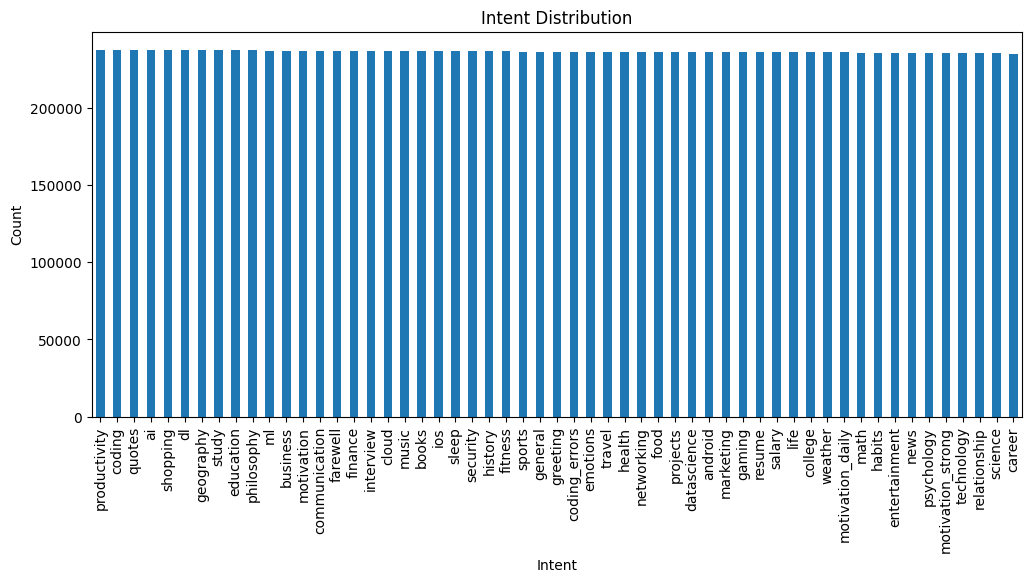

In [8]:
plt.figure(figsize=(12,5))

df['intent'].value_counts().plot(kind='bar')

plt.title("Intent Distribution")

plt.xlabel("Intent")

plt.ylabel("Count")

plt.show()

# 📏 Message Length Analysis

Analyzing message lengths.

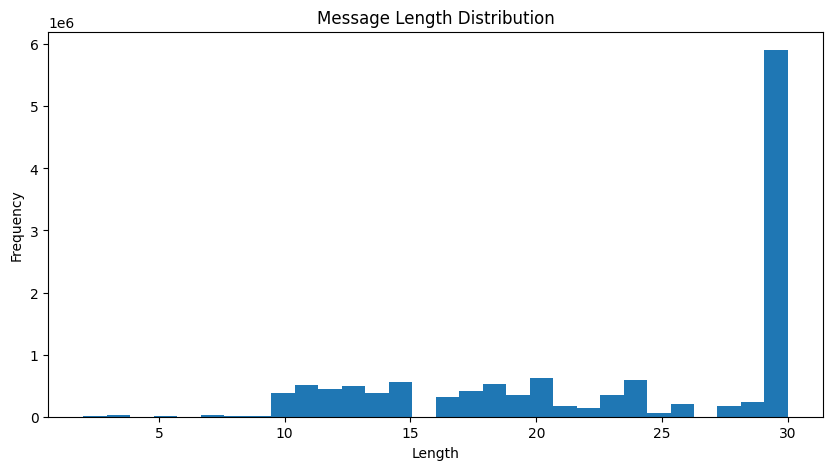

In [9]:
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(10,5))

plt.hist(df['message_length'], bins=30)

plt.title("Message Length Distribution")

plt.xlabel("Length")

plt.ylabel("Frequency")

plt.show()

# ☁️ WordCloud Visualization

Displaying most frequent words.

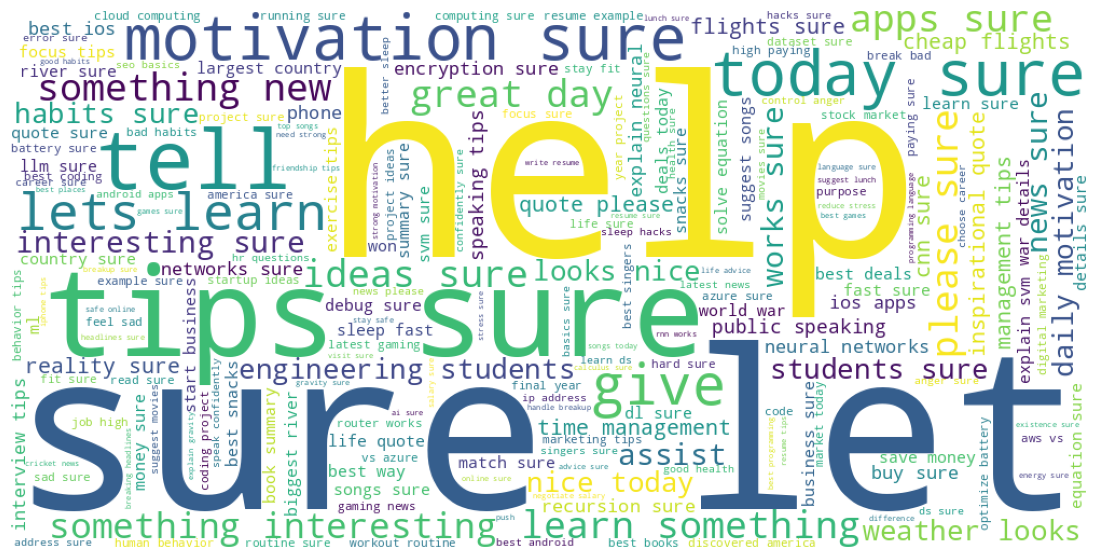

In [10]:
from wordcloud import WordCloud
text = " ".join(df['message'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

# 🔀 Feature and Label Separation

- X → messages
- y → intents

In [11]:
X = df['message'].values

y = df['intent'].values

# 🔢 Tokenization

Converting text into numerical tokens.

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()

tokenizer.fit_on_texts(X)

2026-05-12 12:50:28.010704: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778590228.174818      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778590228.225688      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778590228.603001      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778590228.603053      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778590228.603056      24 computation_placer.cc:177] computation placer alr

# 🔄 Convert Text into Sequences

Transforming text into integer sequences.

In [13]:
X_seq = tokenizer.texts_to_sequences(X)

print(X_seq[:5])

[[13, 99, 14], [3, 4, 1, 5, 2, 6, 7], [11, 10, 96], [3, 4, 1, 5, 2, 6, 7], [28, 63]]


# 📐 Sequence Padding

Padding ensures equal sequence length.

In [14]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 10

X_pad = pad_sequences(
    X_seq,
    maxlen=max_length,
    padding='post'
)

print(X_pad[:5])

[[13 99 14  0  0  0  0  0  0  0]
 [ 3  4  1  5  2  6  7  0  0  0]
 [11 10 96  0  0  0  0  0  0  0]
 [ 3  4  1  5  2  6  7  0  0  0]
 [28 63  0  0  0  0  0  0  0  0]]


# 🏷️ Label Encoding

Encoding intent labels into numbers.

In [15]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(y_encoded[:10])

[48 48  0  0 23 23  2  2  8  8]


# ✂️ Train-Test Split

Splitting dataset into:
- Training Set
- Testing Set

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pad,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# 🧠 Building LSTM Model

The architecture contains:
- Embedding Layer
- LSTM Layer
- Dropout Layer
- Dense Output Layer

In [17]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)
vocab_size = len(tokenizer.word_index) + 1

model = Sequential()

# 🔤 Embedding Layer

Converts words into dense vector representations.

In [18]:
model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


# 🧠 LSTM Layer

Captures sequence patterns and contextual information.

In [19]:
model.add(
    LSTM(
        128,
        return_sequences=False
    )
)

I0000 00:00:1778590484.888500      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# 🚫 Dropout Layer

Helps reduce overfitting.

In [20]:
model.add(Dropout(0.5))

# 🎯 Output Layer

Predicting final intent category.

In [21]:
model.add(
    Dense(
        len(label_encoder.classes_),
        activation='softmax'
    )
)

# ⚙️ Model Compilation

Compiling the model using:
- Sparse Categorical Crossentropy
- Adam Optimizer
- Accuracy Metric

In [22]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 🏗️ Model Summary

Displaying complete architecture.

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 🚀 Model Training

Training the LSTM neural network.

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/5


I0000 00:00:1778590489.826093      70 cuda_dnn.cc:529] Loaded cuDNN version 91002


324903/324903 ━━━━━━━━━━━━━━━━━━━━ 1982s 6ms/step - accuracy: 0.5514 - loss: 1.7942 - val_accuracy: 0.5547 - val_loss: 1.7782
Epoch 2/5
324903/324903 ━━━━━━━━━━━━━━━━━━━━ 1990s 6ms/step - accuracy: 0.5546 - loss: 1.7784 - val_accuracy: 0.5546 - val_loss: 1.7783
Epoch 3/5
324903/324903 ━━━━━━━━━━━━━━━━━━━━ 2025s 6ms/step - accuracy: 0.5543 - loss: 1.7801 - val_accuracy: 0.5546 - val_loss: 1.7781
Epoch 4/5
324903/324903 ━━━━━━━━━━━━━━━━━━━━ 2040s 6ms/step - accuracy: 0.5544 - loss: 1.7789 - val_accuracy: 0.5546 - val_loss: 1.7783
Epoch 5/5
324903/324903 ━━━━━━━━━━━━━━━━━━━━ 2027s 6ms/step - accuracy: 0.5547 - loss: 1.7779 - val_accuracy: 0.5546 - val_loss: 1.7781


# 📈 Accuracy Visualization

Visualizing training and validation accuracy.

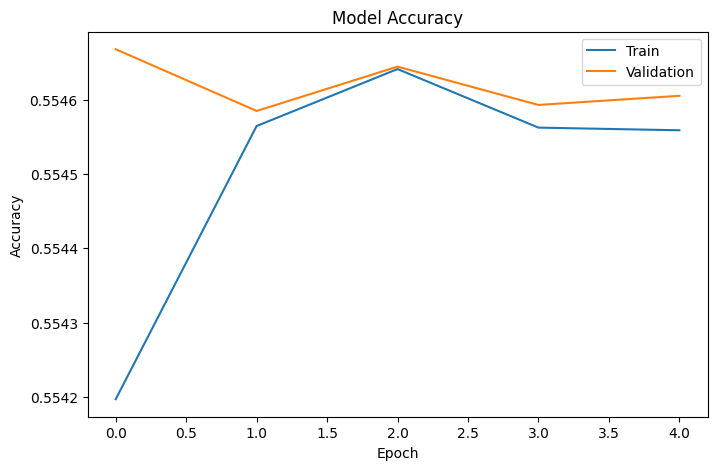

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

# 📉 Loss Visualization

Visualizing training and validation loss.

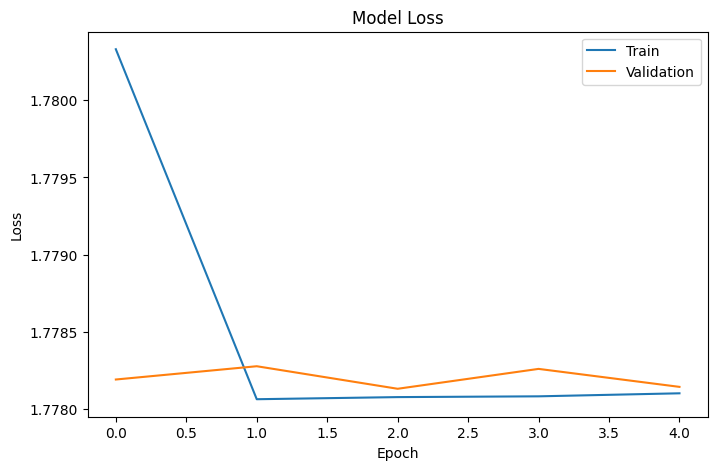

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

# 💾 Save Trained Model

Saving trained model for future use.

In [27]:
model.save("lstm_chatbot_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!


# 🤖 Prediction Function

Creating real-time intent prediction system.

In [28]:
def predict_intent(text):

    text = clean_text(text)

    seq = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        seq,
        maxlen=max_length,
        padding='post'
    )

    prediction = model.predict(padded)

    predicted_class = np.argmax(prediction)

    intent = label_encoder.inverse_transform(
        [predicted_class]
    )

    return intent[0]

# 🧪 Real-Time Chatbot Testing

Testing the trained chatbot model.

In [29]:
while True:

    user_input = input("You: ")

    if user_input.lower() == "exit":
        break

    result = predict_intent(user_input)

    print("Predicted Intent:", result)

StdinNotImplementedError: raw_input was called, but this frontend does not support input requests.